Rows: 165 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): id, source, country, host
dbl (1): ST

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


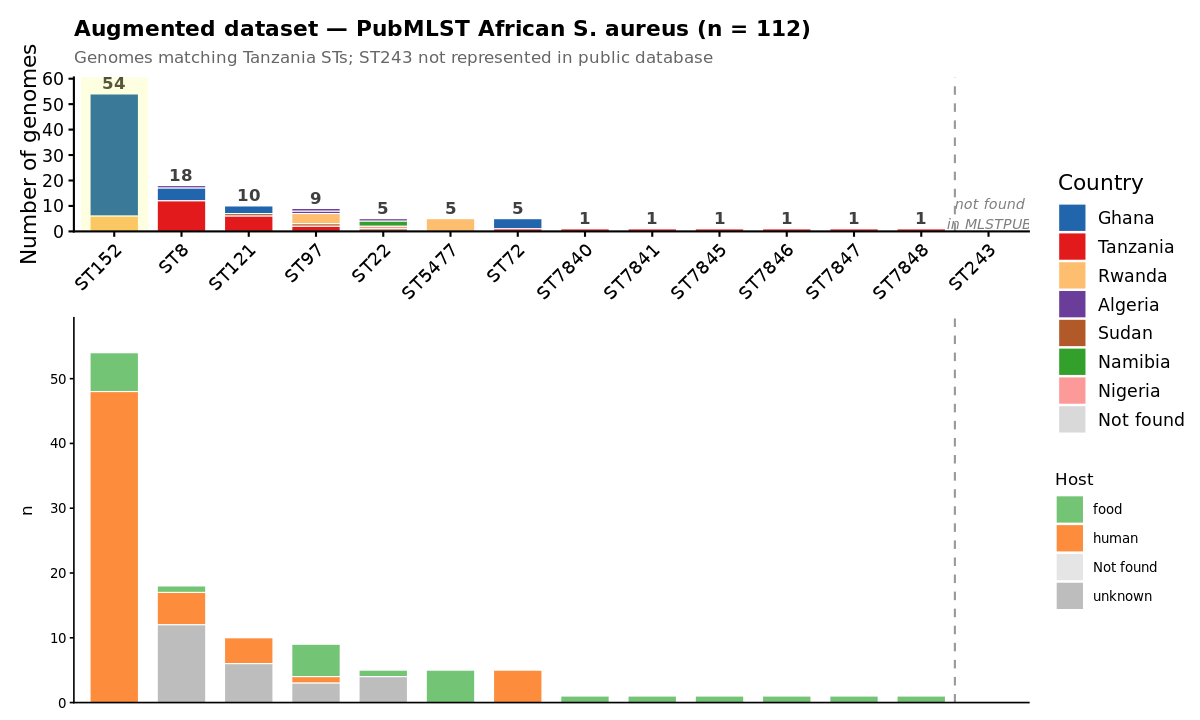

In [ ]:
library(ggplot2)
library(dplyr)
library(forcats)
library(tidyr)
library(RColorBrewer)
library(readr)


options(repr.plot.width = 10, repr.plot.height = 6)

# 
Load data 
df <- read_tsv("../../results_for_analysis/metadata/joined_filtered.tsv")

# 
Filter to MLSTPUB only 
pub <- df |>
  filter(source == "MLSTPUB") |>
  mutate(ST = as.character(ST))

# 
Define the full ST axis: all Tanzania STs (including ST243, not in MLSTPUB)
# This ensures ST243 appears as an empty bar with a "not found" label
tanzania_sts <- c("8","22","72","97","121","152","243",
                  "5477","7840","7841","7845","7846","7847","7848")

# Order: by MLSTPUB total frequency descending, ST243 last (it has 0)
st_order <- pub |>
  count(ST) |>
  arrange(desc(n)) |>
  pull(ST)

# Add ST243 at the end (not found in MLSTPUB)
st_order_full <- c(st_order, "243")

# 
Count per ST x country x host 
counts <- pub |>
  count(ST, country, host) |>
  # Add ST243 as an explicit zero row so it appears on the axis
  bind_rows(tibble(ST = "243", country = NA_character_,
                   host = NA_character_, n = 0)) |>
  mutate(
    ST      = factor(paste0("ST", ST), levels = paste0("ST", st_order_full)),
    country = replace_na(country, "Not found"),
    host    = replace_na(host, "Not found")
  )

# 
Colour palettes 
country_pal <- c(
  "Ghana"     = "#2166AC",
  "Tanzania"  = "#E31A1C",
  "Rwanda"    = "#FDBF6F",
  "Algeria"   = "#6A3D9A",
  "Sudan"     = "#B15928",
  "Namibia"   = "#33A02C",
  "Nigeria"   = "#FB9A99",
  "Not found" = "grey85"
)

host_shapes <- c(
  "human"     = 21,   # circle
  "food"      = 22,   # square
  "unknown"   = 23,   # diamond
  "Not found" = 4     # cross
)

# 
Main bar plot: filled by country 
# Totals for label above each bar
totals <- counts |>
  group_by(ST) |>
  summarise(total = sum(n), .groups = "drop")

p <- ggplot(counts, aes(x = ST, y = n, fill = country)) +
  # bars
  geom_col(width = 0.72, color = "white", linewidth = 0.3) +
  # "not found" annotation for ST243
  annotate("text",
    x     = "ST243",
    y     = 0.8,
    label = "not found\nin MLSTPUB",
    size  = 3, color = "grey50", fontface = "italic", hjust = 0.5, vjust = 0
  ) +
  # total count above each bar (skip ST243)
  geom_text(
    data = totals |> filter(ST != "ST243"),
    aes(x = ST, y = total, label = total, fill = NULL),
    vjust = -0.4, size = 3.5, color = "grey25", fontface = "bold"
  ) +
  # subtle highlight behind ST152
  annotate("rect",
    xmin = 0.5, xmax = 1.5,   # ST152 is first bar (highest n)
    ymin = 0,   ymax = Inf,
    fill = "#eeff01", alpha = 0.12
  ) +
  scale_fill_manual(
    values = country_pal,
    name   = "Country",
    breaks = c("Ghana","Tanzania","Rwanda","Algeria","Sudan","Namibia","Nigeria","Not found")
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.12)),
    breaks = seq(0, 60, 10)
  ) +
  labs(
    title    = "Augmented dataset — PubMLST African S. aureus (n = 112)",
    subtitle = "Genomes matching Tanzania STs; ST243 not represented in public database",
    x        = NULL,
    y        = "Number of genomes"
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title      = element_text(face = "bold", size = 13),
    plot.subtitle   = element_text(color = "grey40", size = 10),
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 11),
    legend.position = "right",
    # dashed separator before ST243
    panel.grid.major.x = element_blank()
  ) +
  # vertical dashed line before ST243 to visually separate it
  geom_vline(xintercept = length(st_order) + 0.5,
             linetype = "dashed", color = "grey60", linewidth = 0.6)

# 
Host annotation strip (small dots above bars) 
# Summarise host per ST for annotation
host_summary <- pub |>
  count(ST, host) |>
  bind_rows(tibble(ST = "243", host = "Not found", n = 0)) |>
  mutate(ST = factor(paste0("ST", ST), levels = paste0("ST", st_order_full)))

p_host <- ggplot(host_summary, aes(x = ST, y = n, fill = host)) +
  geom_col(width = 0.72, color = "white", linewidth = 0.3) +
  scale_fill_manual(
    values = c("human"     = "#FD8D3C",
               "food"      = "#74C476",
               "unknown"   = "#BDBDBD",
               "Not found" = "grey90"),
    name = "Host"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  geom_vline(xintercept = length(st_order) + 0.5,
             linetype = "dashed", color = "grey60", linewidth = 0.6) +
  labs(x = NULL, y = "n") +
  theme_classic(base_size = 10) +
  theme(
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "right"
  )

# 
Combine with patchwork 
library(patchwork)

final <- p / p_host +
  plot_layout(heights = c(1.2, 3), guides = "collect") &
  theme(legend.position = "right")

final